In [67]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from quantum_logical.channel import AmplitudeDamping, PhaseDamping
from quantum_logical.trotter import TrotterGroup
from tqdm import tqdm
from quantum_logical.operators import selective_destroy
from scipy.optimize import curve_fit

In [68]:
# generating parameters and creating initial state
T1 = 50
T2 = 25
N = 5
dim = 2
trotter_dt = .01
# psi0 = qt.tensor((qt.basis(dim, 1)).unit(), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0))
# psi0 = qt.basis(dim, 1)
# rho0 = psi0 * psi0.dag()
amp_damp_channel = AmplitudeDamping(T1, num_qubits=N, hilbert_space_dim=dim)
phase_damp_channel = PhaseDamping(T1, T2, num_qubits=N, hilbert_space_dim=dim)
trotter = TrotterGroup(
    continuous_operators=[amp_damp_channel, phase_damp_channel],
    trotter_dt=trotter_dt,
)


# qt.Qobj(amp_damp_channel._create_single_qubit_operators(T1=1)[1])
# identity = qt.qeye(dim ** N)

In [69]:
# creating the set of cnots
cnot1 = qt.cnot(N=5, control=0, target=1)
cnot2 = qt.cnot(N=5, control=0, target=2)

cnot3 = qt.cnot(N=5, control=0, target=3)
cnot4 = qt.cnot(N=5, control=1, target=3)

cnot5 = qt.cnot(N=5, control=1, target=4)
cnot6 = qt.cnot(N=5, control=2, target=4)

z_gate = qt.Qobj([[1, 0], [0, -1]])

hada = 1/np.sqrt(2) * qt.Qobj([[1, 1], [1, -1]])

hada_layer = qt.tensor(hada, hada, hada, qt.qeye(dim), qt.qeye(dim))

/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_75818/2090992508.py:2: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot1 = qt.cnot(N=5, control=0, target=1)
/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_75818/2090992508.py:3: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot2 = qt.cnot(N=5, control=0, target=2)
/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_75818/2090992508.py:5: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instea

In [70]:
# creating the initial state and encoding it 
# psi0 = qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0))
psi0 = qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0))
rho0 = psi0 * psi0.dag()
rho_encoded = cnot2 * cnot1 * rho0 * cnot1.dag() * cnot2.dag()
rho_encoded = hada_layer * rho_encoded * hada_layer.dag()
# trace out the ancillas to get the true result
rho_encoded_traced = qt.ptrace(rho_encoded, [0, 1, 2])
# the correct initial state has been prepared 
rho_encoded_traced 
# store the states and the fidelities that come out
states = []
fids = []
# states.append(hada_layer * rho_encoded * hada_layer.dag())
states.append(hada_layer * rho_encoded * hada_layer.dag())
fids.append(qt.fidelity(rho_encoded, rho_encoded))

In [71]:
qt.ptrace(hada_layer * rho_encoded * hada_layer.dag(), [0,1,2])

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]

In [72]:
# # store the states and the fidelities that come out
# states = []
# fids = []

In [73]:
# run the circuit 
# initial_time = .02
# initial_state_relax = trotter.apply(rho_encoded, duration=initial_time, discrete_unitary=qt.qeye(dim ** N))
# for i in range(len(initial_state_relax)):
#     a = qt.ptrace(initial_state_relax[i], [0, 1, 2])
#     states.append(hada_layer * initial_state_relax[i] * hada_layer.dag()) # storing the state in the computational basis 
#     fids.append(qt.fidelity(a, rho_encoded_traced))

# now apply the cnots to the circuit 
cnot_gate_overall = cnot6 * cnot5 * cnot4 * cnot3
cnot_gate_overall = hada_layer * cnot_gate_overall * hada_layer.dag()

# rho_hada_pre_cnot = hada_layer * initial_state_relax[-1] * hada_layer.dag()
rho_hada_pre_cnot = rho_encoded



syndrome_time = .4
after_syndrome_extraction = trotter.apply(rho_hada_pre_cnot, duration= syndrome_time, discrete_unitary=cnot_gate_overall)
for i in range(len(after_syndrome_extraction)):
    a = hada_layer * after_syndrome_extraction[i] * hada_layer.dag() # need to do this in order to get the right fidelity in the correct basis 
    # a = after_syndrome_extraction[i]
    states.append(a)
    # states.append(after_syndrome_extraction[i])
    # states.append(a)
    a = after_syndrome_extraction[i]
    a = qt.ptrace(a, [0, 1, 2])
    fids.append(qt.fidelity(a, rho_encoded_traced))


f = after_syndrome_extraction[-1]


In [74]:
# projective measurement 
projection_operator_00 = qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0))).dag()))
projection_operator_01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1))).dag()))
projection_operator_10 = qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0))).dag())) 
projection_operator_11 = qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1))).dag()))

In [75]:
a = (projection_operator_00 * f).tr()
b = (projection_operator_01 * f).tr()
c = (projection_operator_10 * f).tr()
d = (projection_operator_11 * f).tr()
d == np.trace(projection_operator_11 * states[-1] * projection_operator_11.dag())

False

In [76]:
# apply the recovery gate
# measurement step is instantaneous 
rho00 = projection_operator_00 * f * projection_operator_00.dag() / np.trace(projection_operator_00 * f * projection_operator_00.dag())
rho01 = projection_operator_01 * f * projection_operator_01.dag() / np.trace(projection_operator_01 * f * projection_operator_01.dag())
rho10 = projection_operator_10 * f * projection_operator_10.dag() / np.trace(projection_operator_10 * f * projection_operator_10.dag())
rho11 = projection_operator_11 * f * projection_operator_11.dag() / np.trace(projection_operator_11 * f * projection_operator_11.dag())

# now you have to trotterize all of these separately and then bring them back together this is a way to get around this but roger thinks its dumb 
# correction_operators
r00 = hada_layer * qt.tensor([qt.qeye(dim)] * 5) * hada_layer.dag()
r01 = hada_layer * qt.tensor(qt.qeye(dim), qt.qeye(dim), z_gate, qt.tensor([qt.qeye(dim)] * 2)) * hada_layer.dag()
r10 = hada_layer * qt.tensor(z_gate, qt.tensor([qt.qeye(dim)] * 4)) * hada_layer.dag()
r11 = hada_layer * qt.tensor(qt.qeye(dim), z_gate, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2)) * hada_layer.dag()

In [77]:
rho00 = hada_layer * rho00 * hada_layer.dag()
rho01 = hada_layer * rho01 * hada_layer.dag()
rho10 = hada_layer * rho10 * hada_layer.dag()
rho11 = hada_layer * rho11 * hada_layer.dag()

In [78]:
# # recovery algorithm
# correction_op = (r00 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0))).dag())).full()) +
#                  r01 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1))).dag())).full()) +
#                  r10 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0))).dag())).full()) +
#                  r11 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1))).dag())).full())
# )

recovery_time = .02

# measurement = trotter.apply(final_state, duration=measurement_dur, discrete_unitary=qt.qeye(dim ** N))
recovery1 = trotter.apply(rho00, duration=recovery_time, discrete_unitary=r00)
# states.extend(recovery1)
# fids.append(qt.fidelity(qt.ptrace(recovery1[-1], [0, 1, 2]), rho_encoded_traced))
recovery2 = trotter.apply(rho01, duration=recovery_time, discrete_unitary=r01)
recovery3 = trotter.apply(rho10, duration=recovery_time, discrete_unitary=r10)
recovery4 = trotter.apply(rho11, duration=recovery_time, discrete_unitary=r11)

# have to add them back to get the overall density matrix 
for i in range(len(recovery1)):
    total_state = (a * recovery1[i] + 
                   b * recovery2[i] + 
                   c * recovery3[i] + 
                   d * recovery4[i])
    total_state_normal = total_state / np.trace(total_state)
    total_state_normal = hada_layer * total_state_normal * hada_layer.dag()
    total_state_trace = qt.ptrace(total_state_normal, [0, 1, 2])
    # total_state_normal = hada_layer * total_state_normal * hada_layer.dag()
    fids.append(qt.fidelity(total_state_trace, rho_encoded_traced)) # doing this in order to put the state in the computational basis 
    states.append(hada_layer * total_state_normal * hada_layer.dag())

total_time = recovery_time + syndrome_time

time = np.linspace(0, total_time, len(fids))

In [79]:
qt.ptrace(hada_layer * states[-1] * hada_layer.dag(), [0,1,2])

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[0.12529266+0.00000000e+00j 0.12514606+6.36955241e-05j
  0.12514605+6.37088762e-05j 0.12499982+1.27216867e-04j
  0.12514606+6.36955241e-05j 0.12499979+1.27203523e-04j
  0.12499982+1.27216867e-04j 0.12485379+1.90537661e-04j]
 [0.12514606-6.36955241e-05j 0.12509735+0.00000000e+00j
  0.12499982+1.33371649e-08j 0.12495107+6.35588358e-05j
  0.12499979-3.49385884e-15j 0.12495108+6.35454876e-05j
  0.12485379+6.35214072e-05j 0.12480517+1.26917188e-04j]
 [0.12514605-6.37088762e-05j 0.12499982-1.33371624e-08j
  0.12509734+0.00000000e+00j 0.12495107+6.35454996e-05j
  0.12499982-1.33371618e-08j 0.12485379+6.34947478e-05j
  0.12495107+6.35454996e-05j 0.12480513+1.26903872e-04j]
 [0.12499982-1.27216867e-04j 0.12495107-6.35588358e-05j
  0.12495107-6.35454996e-05j 0.12490244+0.00000000e+00j
  0.12485379-6.35214072e-05j 0.12480517-1.33333538e-08j
  0.12480513+1.54742050e-14j 0.12475651+6.33958047e-05j

In [80]:
state_new = []
for i in range(len(states)):
    state_new.append(qt.ptrace(states[i], [0, 1, 2]))

(9.992007221626409e-16+0j)
0j
0j
0j
0j
0j
0j
0j


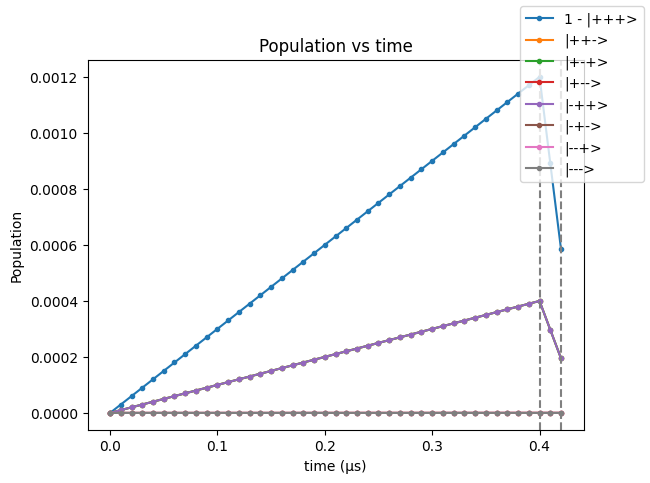

In [81]:
# make a plot of the states 
# graph the results
fig, ax = plt.subplots()
# for i in range(dim ** 3):
bf = ["1 - |+++>", "|++->", "|+-+>", "|+-->", "|-++>", "|-+->", "|--+>", "|--->"]
for i in range(dim ** 3):
    data = []
    for j in range(len(state_new)):
    #     if i != 7:
        # data.append(state_new[j][i, i])
    #     elif i == 7:
    #         data.append(1 - state_new[j][i, i])
        if i != 0:
            data.append(state_new[j][i,i])
        elif i == 0:
            # data.append(1 - state_new[j][i,i])
            data.append(1 - state_new[j][i,i])
    print(min(data))
    ax.plot(time, data, label = bf[i], marker = ".")


fig.legend(loc = "upper right")
ax.set_title("Population vs time")
ax.set_ylabel("Population")
ax.set_xlabel(u"time (\u03bcs)")

# stages = [.4, .41]
stages = [.4, .42]
for i in stages:
    ax.axvline(x=i, color='grey', linestyle='--')

In [82]:
data[-1]

(1.1826550265403538e-07+0j)

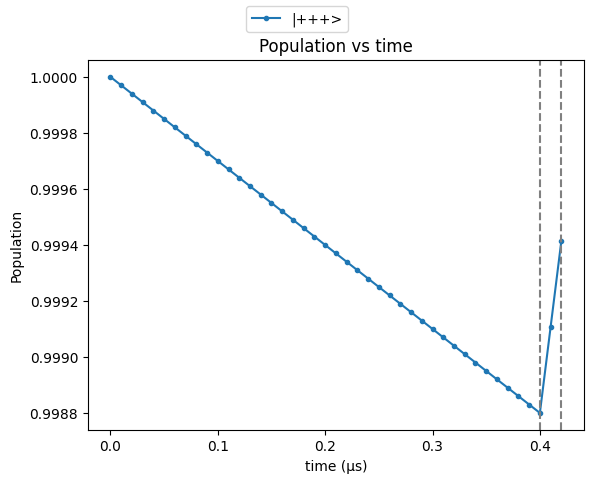

In [83]:
fig, ax = plt.subplots()
data = []
for i in range(len(state_new)):
    data.append(state_new[i][0, 0])
ax.plot(time, data, label = "|+++>", marker = ".")

ax.set_title("Population vs time")
ax.set_ylabel("Population")
ax.set_xlabel(u"time (\u03bcs)")
fig.legend(loc = "upper center")

stages = [.4, .42]
for i in stages:
    ax.axvline(x=i, color='grey', linestyle='--')

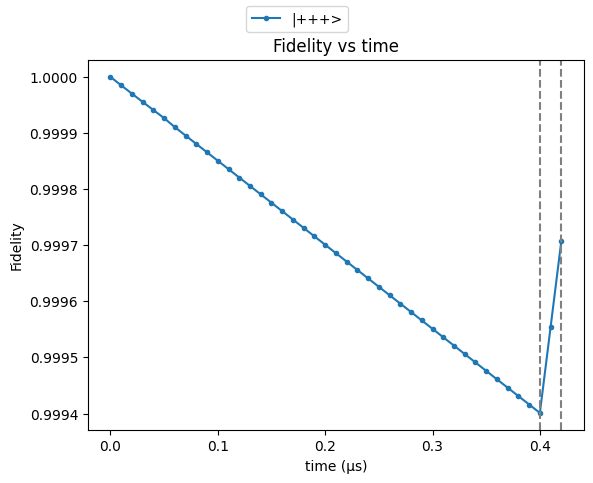

In [84]:
# fidelity plots 
fig, ax = plt.subplots()
ax.plot(time, fids, label = "|+++>", marker = ".")

ax.set_title("Fidelity vs time")
ax.set_ylabel("Fidelity")
ax.set_xlabel(u"time (\u03bcs)")
fig.legend(loc = "upper center")

# stages = [0, .428, .47]
stages = [.4, .42]
for i in stages:
    ax.axvline(x=i, color='grey', linestyle='--')

In [49]:
# creating the initial state and encoding it 
psi0 = qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0))
rho0 = psi0 * psi0.dag()
rho_encoded = cnot2 * cnot1 * rho0 * cnot1.dag() * cnot2.dag()
rho_encoded = hada_layer * rho_encoded * hada_layer.dag()
# trace out the ancillas to get the true result
rho_encoded_traced = qt.ptrace(rho_encoded, [0, 1, 2])
# the correct initial state has been prepared 
rho_encoded_traced 

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
 [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
 [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
 [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
 [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
 [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
 [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
 [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]]

In [50]:
# build the basic experiment first for regular detection
compare_state = []
compare_fids = []
total_time = 559.77
# rho_encoded_1 = hada_layer * rho_encoded * hada_layer.dag()
rho_plot = trotter.apply(rho_encoded, duration=total_time, discrete_unitary=qt.qeye(dim  ** N))
for i in range(len(rho_plot)):
    a = qt.ptrace(rho_plot[i], [0, 1, 2])
    compare_fids.append(qt.fidelity(a, rho_encoded_traced))
    a = hada_layer * rho_plot[i] * hada_layer.dag()
    a = qt.ptrace(a, [0, 1, 2])
    compare_state.append(a)

time = np.linspace(0, total_time, len(compare_state))

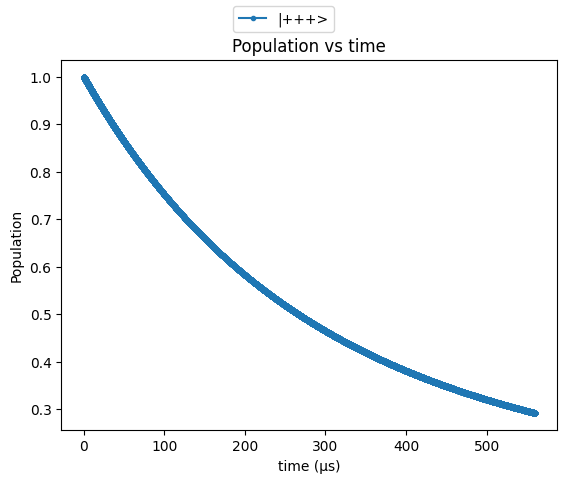

In [51]:
fig, ax = plt.subplots()
# can change the data in the ax function to compare fids in order to get results for the fids
data = []
for i in range(len(compare_state)):
    data.append(compare_state[i][0,0])
ax.plot(time, data, label = "|+++>", marker = ".")


ax.set_xlabel(u"time (\u03bcs)")
ax.set_ylabel("Population")
ax.set_title("Population vs time")
# label this as idle 

fig.legend(loc = "upper center")
# # fitting the data
# def function_fit(t, b):
#     return np.exp(-t / b)

# parameters, covariance = curve_fit(function_fit, time, data)

# fit_func = function_fit(time, parameters[0])
# ax.plot(time, fit_func, color = "black", linestyle = "-", label = "fitted line")
# # plt.plot(time_idle, datas, color = "orange", marker = ".", alpha = 0.01)


# T1_idle = parameters[0]
# print(parameters[0]) 

In [22]:
data[-1]

(0.038196472033287285+0j)

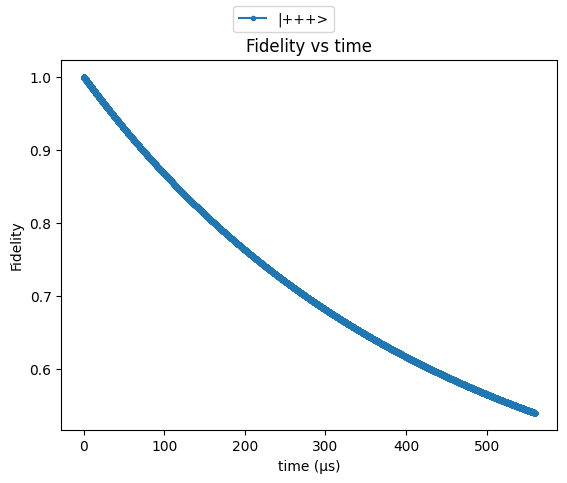

In [23]:
fig, ax = plt.subplots()
# can change the data in the ax function to compare fids in order to get results for the fids
# data = []
# for i in range(len(compare_state)):
#     data.append(compare_state[i][7, 7])
ax.plot(time, compare_fids, label = "|+++>", marker = ".")
ax.set_xlabel(u"time (\u03bcs)")
ax.set_ylabel("Fidelity")
ax.set_title("Fidelity vs time")
# label this as idle 

fig.legend(loc = "upper center")


# # fitting the data
# def function_fit(t, b):
#     return np.exp(-t / b)

In [24]:
compare_fids[-1]

0.540116905414148

In [25]:
def stabilizer(initial_state, checked_state, time_list):
    states = []
    fids = []


    # now apply the cnots to the circuit 
    cnot_gate_overall = cnot6 * cnot5 * cnot4 * cnot3
    cnot_gate_overall = hada_layer * cnot_gate_overall * hada_layer.dag()

    # rho_hada_pre_cnot = hada_layer * initial_state_relax[-1] * hada_layer.dag()
    rho_hada_pre_cnot = rho_encoded



    syndrome_time = .4
    after_syndrome_extraction = trotter.apply(rho_hada_pre_cnot, duration= syndrome_time, discrete_unitary=cnot_gate_overall)
    for i in range(len(after_syndrome_extraction)):
        a = hada_layer * after_syndrome_extraction[i] * hada_layer.dag() # need to do this in order to get the right fidelity in the correct basis 
        # a = after_syndrome_extraction[i]
        states.append(a)
        # states.append(after_syndrome_extraction[i])
        # states.append(a)
        a = after_syndrome_extraction[i]
        a = qt.ptrace(a, [0, 1, 2])
        fids.append(qt.fidelity(a, rho_encoded_traced))


    f = after_syndrome_extraction[-1]


    # f = states[-1]

    # apply the recovery gate
    # measurement step is instantaneous 
    rho00 = projection_operator_00 * f * projection_operator_00.dag() / np.trace(projection_operator_00 * f * projection_operator_00.dag())
    rho01 = projection_operator_01 * f * projection_operator_01.dag() / np.trace(projection_operator_01 * f * projection_operator_01.dag())
    rho10 = projection_operator_10 * f * projection_operator_10.dag() / np.trace(projection_operator_10 * f * projection_operator_10.dag())
    rho11 = projection_operator_11 * f * projection_operator_11.dag() / np.trace(projection_operator_11 * f * projection_operator_11.dag())

    # now you have to trotterize all of these separately and then bring them back together this is a way to get around this but roger thinks its dumb 
    # correction_operators
    r00 = hada_layer * qt.tensor([qt.qeye(dim)] * 5) * hada_layer.dag()
    r01 = hada_layer * qt.tensor(qt.qeye(dim), qt.qeye(dim), z_gate, qt.tensor([qt.qeye(dim)] * 2)) * hada_layer.dag()
    r10 = hada_layer * qt.tensor(z_gate, qt.tensor([qt.qeye(dim)] * 4)) * hada_layer.dag()
    r11 = hada_layer * qt.tensor(qt.qeye(dim), z_gate, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2)) * hada_layer.dag()
    recovery_time = time_list[1]

    # putting the states in the hadamard basis 
    rho00 = hada_layer * rho00 * hada_layer.dag()
    rho01 = hada_layer * rho01 * hada_layer.dag()
    rho10 = hada_layer * rho10 * hada_layer.dag()
    rho11 = hada_layer * rho11 * hada_layer.dag()
    recovery_time = .02

    # measurement = trotter.apply(final_state, duration=measurement_dur, discrete_unitary=qt.qeye(dim ** N))
    recovery1 = trotter.apply(rho00, duration=recovery_time, discrete_unitary=r00)
    # states.extend(recovery1)
    # fids.append(qt.fidelity(qt.ptrace(recovery1[-1], [0, 1, 2]), rho_encoded_traced))
    recovery2 = trotter.apply(rho01, duration=recovery_time, discrete_unitary=r01)
    recovery3 = trotter.apply(rho10, duration=recovery_time, discrete_unitary=r10)
    recovery4 = trotter.apply(rho11, duration=recovery_time, discrete_unitary=r11)

    # have to add them back to get the overall density matrix 
    for i in range(len(recovery1)):
        total_state = (np.trace(projection_operator_00 * f * projection_operator_00.dag()) * recovery1[i] + 
                    np.trace(projection_operator_01 * f * projection_operator_01.dag()) * recovery2[i] + 
                    np.trace(projection_operator_10 * f * projection_operator_10.dag()) * recovery3[i] + 
                    np.trace(projection_operator_11 * f * projection_operator_11.dag()) * recovery4[i])
        total_state_normal = total_state / np.trace(total_state)
        total_state_normal = hada_layer * total_state_normal * hada_layer.dag()
        total_state_trace = qt.ptrace(total_state_normal, [0, 1, 2])
        # total_state_normal = hada_layer * total_state_normal * hada_layer.dag()
        fids.append(qt.fidelity(total_state_trace, rho_encoded_traced)) # doing this in order to put the state in the computational basis 
        states.append(hada_layer * total_state_normal * hada_layer.dag())

    return states, fids

In [26]:
result_states = []
result_fids = []

time_list = [.4, .05]

# doing stabilizers for multiple iterations
iterations = 1191
iter_list = [] # for graphing purposes 

# rho_encoded = hada_layer * rho_encoded * hada_layer.dag()
# building the data
for i in tqdm(range(iterations)):
    iter_list.append(i)
    a, b = stabilizer(initial_state=rho_encoded, checked_state=rho_encoded_traced, time_list=time_list)
    c = b[-1]
    result_states.extend(a)
    result_fids.append(c)
    rho_encoded = hada_layer * result_states[-1] * hada_layer.dag()

100%|██████████| 1191/1191 [04:46<00:00,  4.16it/s]


In [27]:
# create the list of time for the amount of iterations
total_time = iterations * sum(time_list)

time_plot = np.linspace(0, total_time, len(result_states))

# analyze the data
# plotted_fids = []
# for i in range(int(len(result_fids) / 4)):
#     plotted_fids.append(result_fids[i * 4 + 3])  

# trace out the ancillas
state_sim = []
for i in range(len(result_states)):
    state_sim.append(qt.ptrace(result_states[i], [0, 1, 2]))

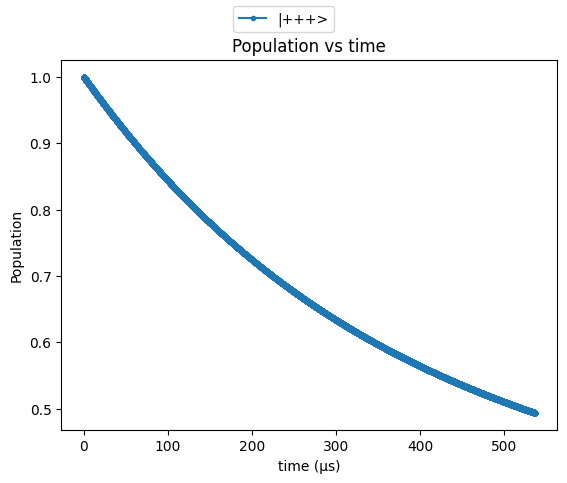

In [28]:
fig, ax = plt.subplots()
data = []
for i in range(len(state_sim)):
    data.append(state_sim[i][0, 0])
ax.plot(time_plot, data, label = "|+++>", marker = ".")


ax.set_xlabel(u"time (\u03bcs)")
ax.set_ylabel("Population")
ax.set_title("Population vs time")
# label this as idle 

fig.legend(loc = "upper center")

# # fitting the data
# def function_fit(t, b):
#     return np.exp(-t / b)

# parameters, covariance = curve_fit(function_fit, time_plot, data)

# fit_func = function_fit(time, parameters[0])
# ax.plot(time, fit_func, color = "black", linestyle = "-", label = "fitted line")
# # plt.plot(time_idle, datas, color = "orange", marker = ".", alpha = 0.01)


# T1_idle = parameters[0]
# print(parameters[0]) 

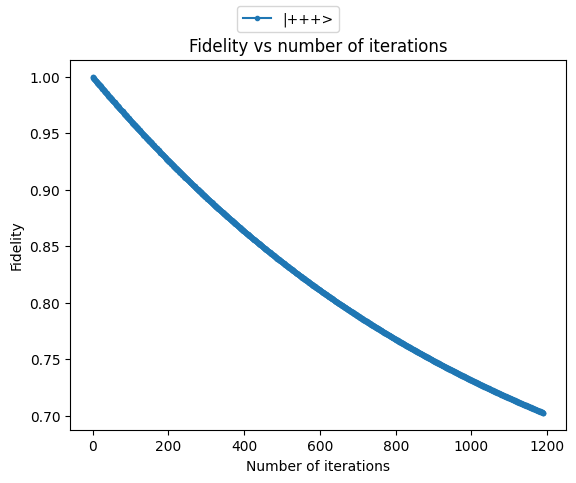

In [29]:
# plot the fids 
fig, ax = plt.subplots()
ax.plot(iter_list, result_fids, label = "|+++>", marker = ".")

ax.set_xlabel("Number of iterations")
ax.set_ylabel("Fidelity")
ax.set_title("Fidelity vs number of iterations")

fig.legend(loc = "upper center")

In [30]:
result_fids[-1]

0.7026980835697506